TREN BULANAN PERMINTAAN AMBULANS (2021)

   Month  Number of Total Ambulance Information
49   Jan                                  20738
48   Feb                                  16789
47   Mar                                  17505
46   Apr                                  14905
45   May                                  17212
44  June                                  17192
43  July                                  16566
42   Aug                                  15101
41  Sept                                  13135
40   Oct                                  11210
39   Nov                                   8276
38   Dec                                   8426


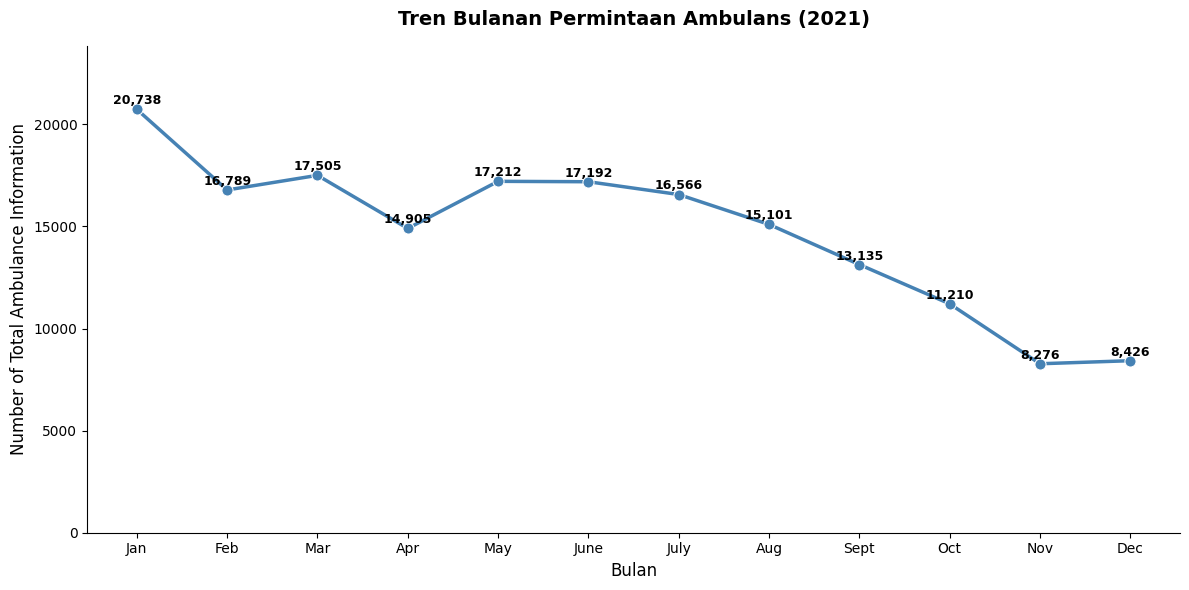

In [2]:
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

# Baca file Excel
df = pd.read_excel("Data.xlsx")

# Filter data tahun 2021
df_2021 = df[df["Year"] == 2021].copy()

# Urutkan berdasarkan bulan (Jan - Dec)
urutan_bulan = ["Jan", "Feb", "Mar", "Apr", "May", "June", "July", "Aug", "Sept", "Oct", "Nov", "Dec"]
df_2021["Month"] = pd.Categorical(df_2021["Month"], categories=urutan_bulan, ordered=True)
df_2021 = df_2021.sort_values("Month")

print(df_2021[["Month", "Number of Total Ambulance Information"]])

# Buat Line Chart
fig, ax = plt.subplots(figsize=(12, 6))

sns.lineplot(
    data=df_2021,
    x="Month",
    y="Number of Total Ambulance Information",
    marker="o",
    linewidth=2.5,
    markersize=8,
    color="steelblue",
    ax=ax
)

# Tambahkan label nilai di tiap titik
for _, row in df_2021.iterrows():
    ax.text(
        row["Month"],
        row["Number of Total Ambulance Information"] + 100,
        f'{int(row["Number of Total Ambulance Information"]):,}',
        ha="center", va="bottom",
        fontsize=9, fontweight="bold"
    )

# Konfigurasi tampilan
ax.set_title("Tren Bulanan Permintaan Ambulans (2021)", fontsize=14, fontweight="bold", pad=15)
ax.set_xlabel("Bulan", fontsize=12)
ax.set_ylabel("Number of Total Ambulance Information", fontsize=12)
ax.set_ylim(0, df_2021["Number of Total Ambulance Information"].max() * 1.15)
sns.despine()

plt.tight_layout()
plt.savefig("tren_ambulans_2021.png", dpi=150, bbox_inches="tight")
plt.show()

MEDIAN NUMBER OF TOTAL HEALTH INFORMATION /TAHUN

   Year   Median
0  2016  14408.0
1  2017  10295.5
2  2018  11636.5
3  2019  13030.0
4  2020  40368.0
5  2021  13523.0
6  2022   7344.0
7  2023   6082.5
8  2024   5213.0
9  2025   3497.0


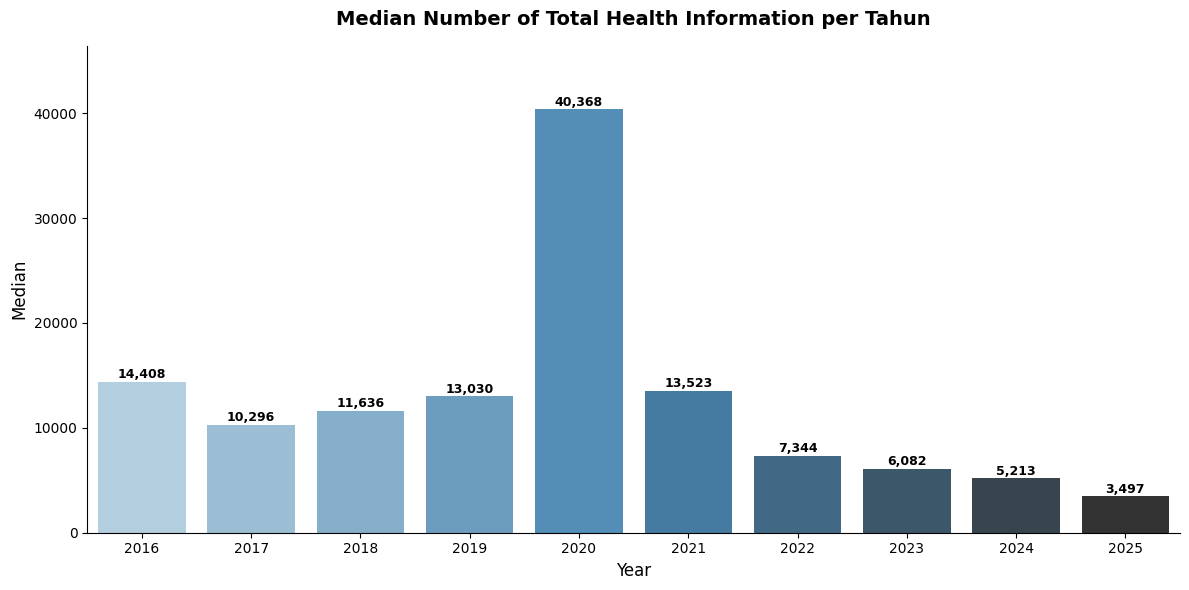

In [3]:
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

# Baca file Excel
df = pd.read_excel("Data.xlsx")

# Hitung median Number of Total Health Information per tahun
median_per_tahun = df.groupby("Year")["Number of Total Health Information"].median().reset_index()
median_per_tahun.columns = ["Year", "Median"]
median_per_tahun["Year"] = median_per_tahun["Year"].astype(int)

print(median_per_tahun)

# Buat Bar Chart
fig, ax = plt.subplots(figsize=(12, 6))

sns.barplot(
    data=median_per_tahun,
    x="Year",
    y="Median",
    hue="Year",
    palette="Blues_d",
    legend=False,
    ax=ax
)

# Tambahkan label nilai di atas tiap bar
for bar, val in zip(ax.patches, median_per_tahun["Median"]):
    ax.text(
        bar.get_x() + bar.get_width() / 2,
        bar.get_height() + 50,
        f"{val:,.0f}",
        ha="center", va="bottom",
        fontsize=9, fontweight="bold"
    )

# Konfigurasi tampilan
ax.set_title("Median Number of Total Health Information per Tahun", fontsize=14, fontweight="bold", pad=15)
ax.set_xlabel("Year", fontsize=12)
ax.set_ylabel("Median", fontsize=12)
ax.set_ylim(0, median_per_tahun["Median"].max() * 1.15)
sns.despine()

plt.tight_layout()
plt.savefig("median_health_info.png", dpi=150, bbox_inches="tight")
plt.show()

MATRIKS KORELAS KLASIFIKASI PANGGILAN MASUK

                                       Total Number of Doctors Consultancy  \
Total Number of Doctors Consultancy                               1.000000   
Number of Total Ambulance Information                             0.848324   
Number of Total Health Information                                0.904190   
Number of Total Complaints                                        0.827180   

                                       Number of Total Ambulance Information  \
Total Number of Doctors Consultancy                                 0.848324   
Number of Total Ambulance Information                               1.000000   
Number of Total Health Information                                  0.820058   
Number of Total Complaints                                          0.933792   

                                       Number of Total Health Information  \
Total Number of Doctors Consultancy                              0.904190   
Number of Total Ambulance Information                 

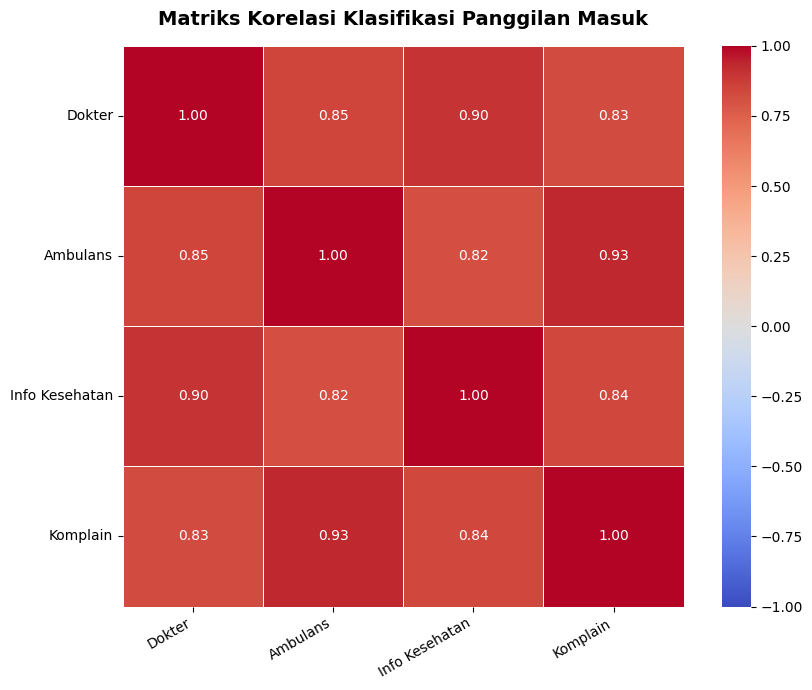

In [4]:
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

# Baca file Excel
df = pd.read_excel("Data.xlsx")

# Pilih kolom klasifikasi panggilan
kolom_panggilan = [
    "Total Number of Doctors Consultancy",
    "Number of Total Ambulance Information",
    "Number of Total Health Information",
    "Number of Total Complaints"
]

# Hitung matriks korelasi
matriks_korelasi = df[kolom_panggilan].corr()

print(matriks_korelasi)

# Buat Heatmap
fig, ax = plt.subplots(figsize=(9, 7))

sns.heatmap(
    matriks_korelasi,
    annot=True,
    fmt=".2f",
    cmap="coolwarm",
    vmin=-1, vmax=1,
    linewidths=0.5,
    linecolor="white",
    square=True,
    ax=ax
)

# Ganti label sumbu agar lebih ringkas
label_ringkas = ["Dokter", "Ambulans", "Info Kesehatan", "Komplain"]
ax.set_xticklabels(label_ringkas, fontsize=10, rotation=30, ha="right")
ax.set_yticklabels(label_ringkas, fontsize=10, rotation=0)

ax.set_title("Matriks Korelasi Klasifikasi Panggilan Masuk", fontsize=14, fontweight="bold", pad=15)

plt.tight_layout()
plt.savefig("heatmap_korelasi.png", dpi=150, bbox_inches="tight")
plt.show()

DISTRIBUSI JUMLAH KOMPLAIN BULANAN

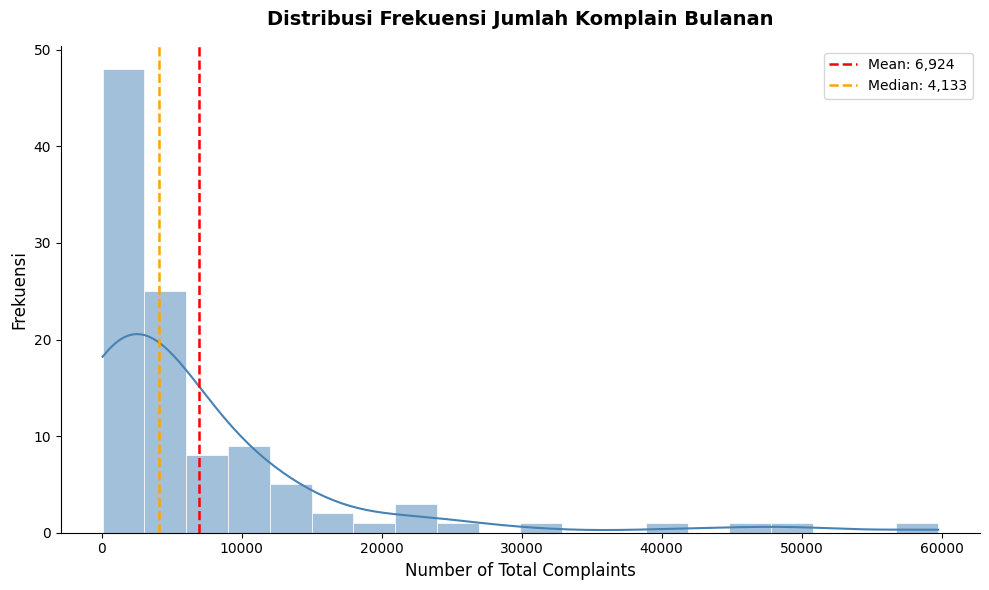

In [5]:
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

# Baca file Excel
df = pd.read_excel("Data.xlsx")

# Buat Histogram + KDE
fig, ax = plt.subplots(figsize=(10, 6))

sns.histplot(
    data=df,
    x="Number of Total Complaints",
    bins=20,
    kde=True,
    color="steelblue",
    edgecolor="white",
    linewidth=0.5,
    ax=ax
)

# Garis vertikal mean dan median
mean_val = df["Number of Total Complaints"].mean()
median_val = df["Number of Total Complaints"].median()

ax.axvline(mean_val, color="red", linestyle="--", linewidth=1.8, label=f"Mean: {mean_val:,.0f}")
ax.axvline(median_val, color="orange", linestyle="--", linewidth=1.8, label=f"Median: {median_val:,.0f}")

# Konfigurasi tampilan
ax.set_title("Distribusi Frekuensi Jumlah Komplain Bulanan", fontsize=14, fontweight="bold", pad=15)
ax.set_xlabel("Number of Total Complaints", fontsize=12)
ax.set_ylabel("Frekuensi", fontsize=12)
ax.legend(fontsize=10)
sns.despine()

plt.tight_layout()
plt.savefig("histogram_komplain.png", dpi=150, bbox_inches="tight")
plt.show()